# Diksha Maharjan
# 2408235

# Task 1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_df = '/content/drive/MyDrive/sem6/week5/FruitinAmazon/train'
test_df = '/content/drive/MyDrive/sem6/week5/FruitinAmazon/test'

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [ ]:
import os
class_names = sorted(os.listdir(train_df))

if not class_names:
    print("No class directories found in the train")
else:
    print(f"Found {len(class_names)} \nclasses: {class_names}")

Found 6 
classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [ ]:
from PIL import Image, UnidentifiedImageError
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_df, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found.")



No corrupted images found.


In [ ]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_df, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


In [ ]:
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_df, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

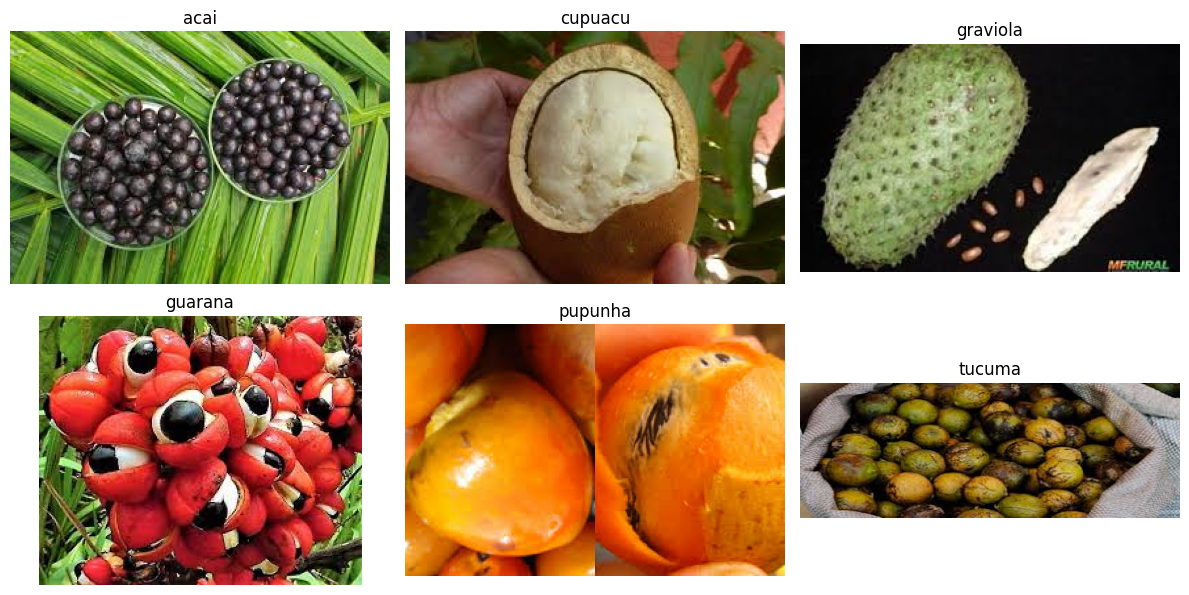

In [ ]:
import matplotlib.image as mpimg

num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def load_datasets(dataset_path, img_size=(128, 128), batch_size=32):
    train_ds = image_dataset_from_directory(
        dataset_path,
        validation_split=0.2,
        subset="training",
        seed=42,
        image_size=img_size,
        batch_size=batch_size
    )
    val_ds = image_dataset_from_directory(
        dataset_path,
        validation_split=0.2,
        subset="validation",
        seed=42,
        image_size=img_size,
        batch_size=batch_size
    )
    return train_ds, val_ds

train_ds, val_ds = load_datasets(train_df)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [ ]:
def build_cnn_model(input_shape, num_classes):
    cnn_model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return cnn_model

input_shape = (128, 128, 3)
class_names = train_ds.class_names
cnn_model = build_cnn_model(input_shape, len(class_names))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
def compile_model(model):
    cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return cnn_model

cnn_model = compile_model(cnn_model)
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def train_model(model, train_ds, val_ds, epochs=250, batch_size=16):
    callbacks = [
        keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True),
        keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
    ]
    cnn_model.fit(train_ds, validation_data=val_ds, epochs=epochs, batch_size=batch_size, callbacks=callbacks)
    return cnn_model

# Example usage:
cnn_model = train_model(cnn_model, train_ds, val_ds)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.1696 - loss: 162.9710

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 368ms/step - accuracy: 0.1806 - loss: 216.0417 - val_accuracy: 0.0556 - val_loss: 179.7602
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.1956 - loss: 174.9889

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 320ms/step - accuracy: 0.1806 - loss: 180.2156 - val_accuracy: 0.2222 - val_loss: 76.7846
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.1944 - loss: 78.8413

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 345ms/step - accuracy: 0.2083 - loss: 72.6026 - val_accuracy: 0.1667 - val_loss: 23.6126
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.3362 - loss: 15.9932

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 293ms/step - accuracy: 0.3056 - loss: 14.3128 - val_accuracy: 0.3889 - val_loss: 3.6556
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.7436 - loss: 0.8051

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 305ms/step - accuracy: 0.7778 - loss: 0.7106 - val_accuracy: 0.2778 - val_loss: 1.7206
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 461ms/step - accuracy: 0.7361 - loss: 0.5846 - val_accuracy: 0.3889 - val_loss: 1.9693
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 506ms/step - accuracy: 0.9722 - loss: 0.2527 - val_accuracy: 0.5000 - val_loss: 2.5426
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 320ms/step - accuracy: 0.9306 - loss: 0.1443 - val_accuracy: 0.5556 - val_loss: 3.2119
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 312ms/step - accuracy: 1.0000 - loss: 0.0256 - val_accuracy: 0.5000 - val_loss: 4.3323
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 279ms/step - accuracy: 1.0000 - loss: 0.0073 - val_accuracy: 0.5000 - val_loss: 5.7717
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 313ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.4444 - val_loss: 6.7267
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 376ms/step - accuracy: 1.0000 - loss: 4.2396e-04 - val_accuracy: 0.5000 - val_lo

In [ ]:
def evaluate_model(model, test_ds):
    test_loss, test_acc = model.evaluate(test_ds)
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f}")

evaluate_model(cnn_model, val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.2778 - loss: 1.7206
Test Accuracy: 0.2778
Test Loss: 1.7206


In [ ]:
def save_model(model, filename="model.h5"):
    model.save(filename)

def load_model(filename="model.h5"):
    return keras.models.load_model(filename)

save_model(cnn_model)
cnn_model = load_model()

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
def make_predictions(model, test_ds, class_names):
    y_true, y_pred = [], []

    for images, labels in test_ds:
        predictions = model.predict(images)
        y_pred.extend(np.argmax(predictions, axis=1))
        y_true.extend(labels.numpy())

    print(classification_report(y_true, y_pred, target_names=class_names))

make_predictions(cnn_model, val_ds, class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
              precision    recall  f1-score   support

        acai       0.50      0.33      0.40         3
     cupuacu       0.00      0.00      0.00         4
    graviola       0.20      1.00      0.33         1
     guarana       0.00      0.00      0.00         3
     pupunha       0.25      0.50      0.33         4
      tucuma       1.00      0.33      0.50         3

    accuracy                           0.28        18
   macro avg       0.33      0.36      0.26        18
weighted avg       0.32      0.28      0.24        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Dropout, BatchNormalization,
                                     Activation, Flatten, Dense)
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

In [ ]:
model = Sequential([
    layers.Lambda(data_augmentation, input_shape=(128, 128, 3)),

    layers.Rescaling(1./255),

    Conv2D(32, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(64, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(128, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(256, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(512, use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(256, use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Output layer
    Dense(6, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    ModelCheckpoint("best_model.h5", save_best_only=True),
    EarlyStopping(patience=10, restore_best_weights=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

test_loss, test_acc = model.evaluate(val_ds)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0995 - loss: 2.3812

3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.1111 - loss: 2.4276 - val_accuracy: 0.0556 - val_loss: 1.7988
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.4444 - loss: 1.5712 - val_accuracy: 0.1667 - val_loss: 1.8022
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3750 - loss: 1.4139 - val_accuracy: 0.2222 - val_loss: 1.8160
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.4583 - loss: 1.3699 - val_accuracy: 0.2222 - val_loss: 1.8556
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.5833 - loss: 1.1007 - val_accuracy: 0.2222 - val_loss: 1.9302
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5833 - loss: 1.1797 - val_accuracy: 0.2222 - val_loss: 2.0355
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.6111 - loss: 0.9867 - val_accuracy: 0.2222 - val_loss: 2.1290
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.7083 - loss: 0.8218 - val_accuracy: 0.2222 - val_loss: 2.2279
Epoch 9/50
3/3 ━━━━━━━

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Task - 2:

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

base_model = VGG16(weights='imagenet',
                  include_top=False,
                  input_shape=(128, 128, 3))


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(6, activation='softmax')(x)

In [ ]:
model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.0001),
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])
callbacks = [
    ModelCheckpoint("best_vgg_model.h5", save_best_only=True),
    EarlyStopping(patience=5, restore_best_weights=True)
]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)
test_loss, test_acc = model.evaluate(val_ds)
print(f"Transfer Learning Model Accuracy: {test_acc:.4f}")
print(f"Transfer Learning Model Loss: {test_loss:.4f}")

from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1308 - loss: 14.6262

3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.1111 - loss: 15.9083 - val_accuracy: 0.0556 - val_loss: 5.8029
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1134 - loss: 15.5583

3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 5s/step - accuracy: 0.1528 - loss: 14.8829 - val_accuracy: 0.2222 - val_loss: 4.1586
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1204 - loss: 14.6377

3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.1111 - loss: 14.5418 - val_accuracy: 0.2778 - val_loss: 4.0819
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2454 - loss: 8.7679

3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.2361 - loss: 8.3733 - val_accuracy: 0.2778 - val_loss: 4.0782
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.2222 - loss: 9.0423 - val_accuracy: 0.2778 - val_loss: 4.1821
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.2500 - loss: 9.6650 - val_accuracy: 0.3333 - val_loss: 4.3253
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.4167 - loss: 5.9121 - val_accuracy: 0.3333 - val_loss: 4.2880
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3802 - loss: 7.4415

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.4722 - loss: 6.5993 - val_accuracy: 0.3889 - val_loss: 3.3055
Epoch 11/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3108 - loss: 7.1671

3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.2917 - loss: 7.4222 - val_accuracy: 0.5000 - val_loss: 2.9356
Epoch 12/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3704 - loss: 7.0408

3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.3611 - loss: 7.3704 - val_accuracy: 0.5556 - val_loss: 2.6257
Epoch 13/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3791 - loss: 6.1659

3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.4028 - loss: 5.6776 - val_accuracy: 0.5000 - val_loss: 2.4963
Epoch 14/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.4444 - loss: 5.3455 - val_accuracy: 0.5556 - val_loss: 2.5462
Epoch 15/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.5000 - loss: 6.2674 - val_accuracy: 0.5000 - val_loss: 2.6388
Epoch 16/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.5972 - loss: 3.5272 - val_accuracy: 0.5556 - val_loss: 2.7445
Epoch 17/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.6250 - loss: 3.3272 - val_accuracy: 0.5556 - val_loss: 2.8727
Epoch 18/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.5556 - loss: 3.2563 - val_accuracy: 0.5556 - val_loss: 2.9978
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 2.4963
Transfer Learning Model Accuracy: 0.5000
Transfer Learning Model Loss: 2.4963

Classification Report:
              precision    recall  f1-score   support

        acai       0.20      0.33  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import classification_report

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_df,
    image_size=(128, 128),  # Original image size
    batch_size=32,
    validation_split=0.2,
    subset='training',
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_df,
    image_size=(128, 128),
    batch_size=32,
    validation_split=0.2,
    subset='validation',
    seed=42
)

class_names = train_ds.class_names
num_classes = len(class_names)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

# Build Transfer Learning Model
inputs = keras.Input(shape=(128, 128, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Resizing(224, 224)(x)

# Load VGG16
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False  #freeze base model

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# train model
callbacks = [
    ModelCheckpoint("best_vgg_model.h5", save_best_only=True),
    EarlyStopping(patience=5, restore_best_weights=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

# evaluate the Model
test_loss, test_acc = model.evaluate(val_ds)
print(f"\nTransfer Learning Model Accuracy: {test_acc:.4f}")
print(f"Transfer Learning Model Loss: {test_loss:.4f}")

# Classification Report
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,980,422 (57.15 MB)

 Trainable params: 265,734 (1.01 MB)

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 14s/step - accuracy: 0.2500 - loss: 1.7498 - val_accuracy: 0.4444 - val_loss: 1.7250
Epoch 26/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3762 - loss: 1.6684  

3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 13s/step - accuracy: 0.3472 - loss: 1.7030 - val_accuracy: 0.4444 - val_loss: 1.7221
Epoch 27/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3814 - loss: 1.6256  

3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 13s/step - accuracy: 0.3472 - loss: 1.6562 - val_accuracy: 0.5000 - val_loss: 1.7219
Epoch 28/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 13s/step - accuracy: 0.3889 - loss: 1.5528 - val_accuracy: 0.4444 - val_loss: 1.7221
Epoch 29/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 13s/step - accuracy: 0.3194 - loss: 1.6455 - val_accuracy: 0.4444 - val_loss: 1.7222
Epoch 30/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.2882 - loss: 1.6301  

3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 13s/step - accuracy: 0.3333 - loss: 1.5926 - val_accuracy: 0.5000 - val_loss: 1.7215
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 0.5000 - loss: 1.7215

Transfer Learning Model Accuracy: 0.5000
Transfer Learning Model Loss: 1.7215

Classification Report:
              precision    recall  f1-score   support

        acai       0.67      0.67      0.67         3
     cupuacu       1.00      0.50      0.67         4
    graviola       0.14      1.00      0.25         1
     guarana       0.67      0.67      0.67         3
     pupunha       0.00      0.00      0.00         4
      tucuma       0.67      0.67      0.67         3

    accuracy                           0.50        18
   macro avg       0.52      0.58      0.49        18
weighted avg       0.56      0.50      0.50        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
